# 自分の約定からコストを推定する

レシピ 04/02 は手数料、スリッページ、レイテンシを振って、結論がそれに耐えるかを見ました。
最初の一手としては正しく、そして明らかな問いが残ります。どの設定が *本当* なのか。
スリッページの推測の誤差よりエッジが小さい戦略は、検証したとは言えません。

この数字は測れます。厚みのある板に対するリプレイは、その板を歩いた約定を生みます。各約定が
仲値からどれだけ離れたかを、表示数量のどれだけを取ったかの関数として見たものが、コスト
モデルです。このレシピでは `quant.costs` でそれを推定し、コストモデルを検証できる唯一の
方法で検証します。もっと安いバックテストにそれを課金して、安いほうがフルの板の結果を
再現するかを確かめます。

## ここで使う用語

| 用語 | 意味 |
| --- | --- |
| スリッページ | 基準にした価格と、実際に得た価格の差 |
| 参加率 | 最良気配に表示されていた数量に対する注文サイズの割合 |
| 実効スプレッド | 片側で測ったスプレッド越えのコストの平均を2倍したもの |
| マーケットインパクト | 注文が大きくなるほど価格がどれだけ悪くなるか |
| 平方根則 | 実証で繰り返し見つかる形。コストはサイズの平方根で増える |
| トップオブブック | 最良ビッドとオファーしか見えず、その後ろの厚みがないバックテスト |
| ティック | 会場が刻む最小の価格単位 |

はじめて見る用語があれば、[GLOSSARY.ja.md](../../GLOSSARY.ja.md) にもう少し詳しい説明があります。ほかのレシピで使う用語もまとめてあります。

In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import backtest
from h5i_db.quant import costs
import cookbook_utils as cu

SYMBOL = "ACME"
TICK = 0.01
PROBE_SIZES = (100, 250, 500, 1_000, 2_000, 4_000, 8_000)

## 1. 最良気配の後ろに何かがある板

このセクションのこれまでのレシピは片側1本の気配でした。小さな注文を約定させるには十分ですが、
大きな注文のコストを測るには使えません。このテープは1ティック刻みで8本の価格帯を持ち、
奥へ行くほど数量が大きくなります。

| 列 | 型 | 意味 |
| --- | --- | --- |
| `ts_init` | `timestamp[ns]` | 板イベントが届いた瞬間 |
| `side` | `string` | ビッドは `buy`、オファーは `sell` |
| `price` | `float64` | その価格帯の価格 |
| `size` | `float64` | その価格に表示されている数量 |
| `event_index` | `int64` | 同じ値を持つ行が1つのアトミックな板 |

In [2]:
quotes = cu.make_quotes(symbols=[SYMBOL], days=1, quotes_per_day=2_000, seed=23)
tape = cu.make_equity_tape(
    quotes, levels=8, level_growth=1.6, print_every=3, tick_size=TICK
)
print(f"{tape['book_deltas'].num_rows:,} book rows, "
      f"{tape['book_deltas'].num_rows // (2 * 8):,} events")
tape["book_deltas"].to_pandas().head(9)[["ts_init", "side", "price", "size", "is_last"]]

24,864 book rows, 1,554 events


,ts_init,side,price,size,is_last
0,2026-06-01 13:30:00.067981,buy,289.79,1000.0000,False
1,2026-06-01 13:30:00.067981,buy,289.78,1600.0000,False
2,2026-06-01 13:30:00.067981,buy,289.77,2560.0000,False
3,2026-06-01 13:30:00.067981,buy,289.76,4096.0000,False
4,2026-06-01 13:30:00.067981,buy,289.75,6553.6000,False
5,2026-06-01 13:30:00.067981,buy,289.74,10485.7600,False
6,2026-06-01 13:30:00.067981,buy,289.73,16777.2160,False
7,2026-06-01 13:30:00.067981,buy,289.72,26843.5456,False
8,2026-06-01 13:30:00.067981,sell,289.85,300.0000,False


In [3]:
db = h5i_db.Database(cu.fresh_db("04_calibrating_costs_from_fills"), create=True)
for name, table in tape.items():
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="eight-level ladder")
db.snapshot("l2-v1", tables=list(tape), note="The full book the cost model is fitted on")

book = tape["book_deltas"].to_pandas()
bids, asks = book[book["side"] == "buy"], book[book["side"] == "sell"]
top_bid = bids.loc[bids.groupby("ts_init")["price"].idxmax()].set_index("ts_init")
top_ask = asks.loc[asks.groupby("ts_init")["price"].idxmin()].set_index("ts_init")
quote = pd.DataFrame(
    {
        "bid": top_bid["price"],
        "bid_size": top_bid["size"],
        "bid_depth": bids.groupby("ts_init")["size"].sum(),
        "ask": top_ask["price"],
        "ask_size": top_ask["size"],
        "ask_depth": asks.groupby("ts_init")["size"].sum(),
    }
).sort_index()
quote["mid"] = (quote["bid"] + quote["ask"]) / 2
quote.head()

,bid,bid_size,bid_depth,ask,ask_size,ask_depth,mid
ts_init,,,,,,,
2026-06-01 13:30:00.067981,289.79,1000.0,69916.12160,289.85,300.0,20974.83648,289.820
2026-06-01 13:30:01.150309,289.75,400.0,27966.44864,289.80,200.0,13983.22432,289.775
2026-06-01 13:30:01.964625,289.76,2000.0,139832.24320,289.79,100.0,6991.61216,289.775
2026-06-01 13:30:07.271106,289.81,100.0,6991.61216,289.84,1200.0,83899.34592,289.825
2026-06-01 13:30:09.176965,289.76,200.0,13983.22432,289.80,800.0,55932.89728,289.780


## 2. プローブ注文

コストモデルには、いろいろなサイズの約定が必要です。ここではプローブ注文から得ます。同じ
サイズの階段を、売り買い交互に、場中に散らして出すので、それぞれが別の板に出会います。

実務では自分の過去の約定を使うことになりますが、以下の計算は変わりません。フィクスチャには
売買履歴がありませんし、意図的に間隔をあけた階段のほうが推定を読みやすいので、ここでは
プローブを使います。

In [4]:
instants = pd.DatetimeIndex(book["ts_init"].unique()).sort_values()
probes = []
for index, size in enumerate(PROBE_SIZES * 8):
    at = instants[150 + index * 20]
    probes.append(
        {
            "ts": at.floor("us").to_pydatetime() + dt.timedelta(microseconds=1),
            "instrument_id": SYMBOL,
            "side": "buy" if index % 2 == 0 else "sell",
            "quantity": float(size),
            "kind": "market",
            "tag": f"probe-{size}",
        }
    )
signals = backtest.signal_table(sorted(probes, key=lambda row: row["ts"]))
backtest.create_signal_table(db)
db.append("signals", signals, note="size ladder, both sides")
print(f"{signals.num_rows} probe orders, {len(PROBE_SIZES)} sizes x 8 repeats")
signals.to_pandas().head()

56 probe orders, 7 sizes x 8 repeats


,ts,instrument_id,outcome,side,quantity,kind,limit_price,time_in_force,tag,reduce_only
0,2026-06-01 13:41:46.496481024,ACME,0,buy,100.0,market,NaN,NaN,probe-100,False
1,2026-06-01 13:43:53.775106816,ACME,0,sell,250.0,market,NaN,NaN,probe-250,False
2,2026-06-01 13:46:13.138299904,ACME,0,buy,500.0,market,NaN,NaN,probe-500,False
3,2026-06-01 13:47:49.601224960,ACME,0,sell,1000.0,market,NaN,NaN,probe-1000,False
4,2026-06-01 13:49:17.292925952,ACME,0,buy,2000.0,market,NaN,NaN,probe-2000,False


プローブの実行では手数料をゼロにします。問いは *板* がいくらかかるかであって、手数料の
体系は正確に分かっているので推定は要りません。

In [5]:
probe_run = backtest.run(
    db,
    "cost-probe",
    starting_cash=10_000_000.0,
    signals="signals",
    snapshot="l2-v1",
    fee_kind="proportional",
    fee_rate=0.0,
    equity_interval_nanos=600_000_000_000,
)
probe_fork = db.fork(probe_run["fork"])
fills = probe_fork.read("bt_fills").to_pandas()
orders = probe_fork.read("bt_orders").to_pandas()
print(f"{len(orders)} orders produced {len(fills)} fills")
print(f"fills per order: {len(fills) / len(orders):.1f} on average, "
      f"{fills.groupby('order_id').size().max()} at most")
fills.head()

56 orders produced 194 fills
fills per order: 3.5 on average, 8 at most


,ts,order_id,instrument_id,outcome,side,price,quantity,commission,is_taker,tag
0,2026-06-01 13:41:49.041193,1,ACME,0,buy,290.85,100.0,0.0,True,probe-100
1,2026-06-01 13:44:11.371913,2,ACME,0,sell,290.24,200.0,0.0,True,probe-250
2,2026-06-01 13:44:11.371913,2,ACME,0,sell,290.23,50.0,0.0,True,probe-250
3,2026-06-01 13:46:16.885152,3,ACME,0,buy,290.79,300.0,0.0,True,probe-500
4,2026-06-01 13:46:16.885152,3,ACME,0,buy,290.80,200.0,0.0,True,probe-500


## 3. 注文1本につきサンプル1つ

`SlippageSample` は、判断した時点で立っていた価格と比べた1回の執行です。1つの判断に複数の
約定がぶら下がるので、まず注文ごとの約定を数量加重平均価格にまとめます。部分約定を別々に
数えると、同じ判断を何度も数え、いちばん奥の価格帯の重みがいちばん小さくなってしまいます。

In [6]:
executed = (
    fills.assign(notional=lambda frame: frame["price"] * frame["quantity"])
    .groupby("order_id")
    .agg(
        ts=("ts", "first"),
        side=("side", "first"),
        quantity=("quantity", "sum"),
        notional=("notional", "sum"),
        levels=("price", "nunique"),
    )
)
executed["avg_price"] = executed["notional"] / executed["quantity"]
decision = pd.merge_asof(
    executed.sort_values("ts").reset_index(),
    quote.reset_index()[["ts_init", "mid", "bid_size", "ask_size"]],
    left_on="ts",
    right_on="ts_init",
)
decision["displayed"] = np.where(
    decision["side"] == "buy", decision["ask_size"], decision["bid_size"]
)
samples = [
    costs.SlippageSample(
        direction=1 if row.side == "buy" else -1,
        fill_price=float(row.avg_price),
        reference_price=float(row.mid),
        quantity=float(row.quantity),
        reference_size=float(row.displayed),
    )
    for row in decision.itertuples()
]
decision["slippage"] = [sample.slippage for sample in samples]
decision["participation"] = [sample.participation for sample in samples]
decision[["side", "quantity", "levels", "avg_price", "mid", "slippage", "participation"]].head()

,side,quantity,levels,avg_price,mid,slippage,participation
0,buy,100.0,1,290.8500,290.835,0.0150,0.333333
1,sell,250.0,2,290.2380,290.250,0.0120,1.250000
2,buy,500.0,2,290.7940,290.755,0.0390,1.666667
3,sell,1000.0,2,290.8750,290.905,0.0300,2.000000
4,buy,2000.0,3,290.7228,290.700,0.0228,5.000000


推定の前に、見出しになる数字を2つ。実効スプレッドは往復でのスプレッド越えのコストです。
インプリメンテーション・ショートフォールは、この注文群が1株あたり実際に払った金額で、
数量で加重してあるので、大きな注文は大きさどおりに効きます。

In [7]:
print(f"effective spread          {costs.effective_spread(samples):.4f}")
print(f"implementation shortfall  {costs.implementation_shortfall(samples):.4f} per share")
print(f"quoted spread (median)    {(quote['ask'] - quote['bid']).median():.4f}")

effective spread          0.0770
implementation shortfall  0.0534 per share
quoted spread (median)    0.0500


## 4. 形を推定する

`fit_impact` はスリッページをサイズに回帰します。参加率の平方根に対してか、参加率そのものに
対してかを選べます。既定が平方根なのは、インパクトの実証研究が繰り返し見つける形だからであり、
凹な過程に直線を当てはめると、いちばん重要なところ、つまり戦略に容量があるかを決める大口
注文で、外挿が大きく外れるからです。

In [8]:
sqrt_fit = costs.fit_impact(samples, shape="sqrt")
linear_fit = costs.fit_impact(samples, shape="linear")
pd.DataFrame([sqrt_fit.to_dict(), linear_fit.to_dict()]).round(5)

,intercept,coefficient,shape,r_squared,residual_std,observations,usable
0,0.01865,0.00772,sqrt,0.64098,0.01126,56,True
1,0.02881,0.00095,linear,0.53372,0.01283,56,True


`usable` は統計的検定ではありません。11本の約定から推定したものはコストモデルではない、
という注意書きであり、30本が「そうでないふり」をしてよい慣習上の下限です。

In [9]:
assert sqrt_fit.is_usable, "not enough fills to claim a cost model"
for label, fit in (("sqrt", sqrt_fit), ("linear", linear_fit)):
    print(f"{label:<7} R^2 {fit.r_squared:.3f}  residual {fit.residual_std:.4f}  "
          f"cost at 1x displayed {fit.predict(1.0):.4f}")

sqrt    R^2 0.641  residual 0.0113  cost at 1x displayed 0.0264
linear  R^2 0.534  residual 0.0128  cost at 1x displayed 0.0298


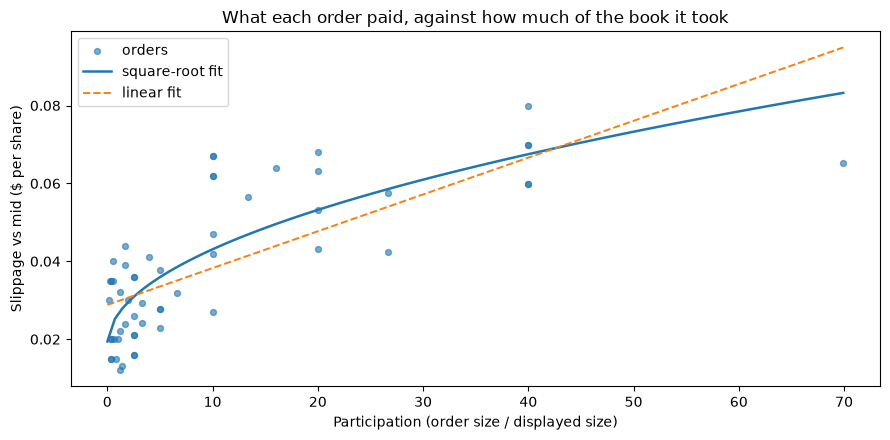

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(decision["participation"], decision["slippage"], s=18, alpha=0.6, label="orders")
grid = np.linspace(0.01, decision["participation"].max(), 100)
ax.plot(grid, [sqrt_fit.predict(x) for x in grid], linewidth=1.8, label="square-root fit")
ax.plot(grid, [linear_fit.predict(x) for x in grid], linewidth=1.4, linestyle="--", label="linear fit")
ax.set_title("What each order paid, against how much of the book it took")
ax.set_xlabel("Participation (order size / displayed size)")
ax.set_ylabel("Slippage vs mid ($ per share)")
ax.legend()
fig.tight_layout()

## 5. 近道と、その前提

`costs.fit_from_fills` は、実行のフォークから引数なしで上のすべてを行います。基準価格を
指定されずに選ぶ必要があるので、同じ瞬間の他の約定の数量加重平均を使います。これは注文が
仲値からどれだけ離れて終わったかより、板をどこまで歩いたかを測ります。

つまりこれは *消費した厚み* の指標で、注文が複数の価格帯を歩いたときにいつでも使えます。
判断時の価格が記録されていない場合に正しい道具です。判断価格が分かっているなら、上のように
自分でサンプルを組み立ててください。

In [11]:
shortcut = costs.fit_from_fills(probe_fork, shape="sqrt")
print(f"shortcut  intercept {shortcut.intercept:+.5f}  coefficient {shortcut.coefficient:+.5f}  "
      f"observations {shortcut.observations}")
print(f"explicit  intercept {sqrt_fit.intercept:+.5f}  coefficient {sqrt_fit.coefficient:+.5f}  "
      f"observations {sqrt_fit.observations}")
print("\nThey answer different questions and should not be expected to agree.")

shortcut  intercept -0.01706  coefficient +0.00049  observations 194
explicit  intercept +0.01865  coefficient +0.00772  observations 56

They answer different questions and should not be expected to agree.


## 6. もっと安い場所にモデルを課金する

コストモデルを推定する理由は、データが測定を支えられない場所で使うためです。日次バーの
バックテストや、トップオブブックの気配しかないリプレイです。この板を片側1本にたたむと、
まさにそのバックテストになります。厚みは全部そこにあり、歩くことはなく、すべて最良気配で
約定します。

In [12]:
sides = pd.concat(
    [
        quote.reset_index()[["ts_init", "bid", "bid_depth"]]
        .rename(columns={"bid": "price", "bid_depth": "size"})
        .assign(side="buy"),
        quote.reset_index()[["ts_init", "ask", "ask_depth"]]
        .rename(columns={"ask": "price", "ask_depth": "size"})
        .assign(side="sell"),
    ]
).sort_values(["ts_init", "side"])
sides["ts_event"] = sides["ts_init"]
sides["instrument_id"] = SYMBOL
sides["outcome"] = 0
sides["action"] = "snapshot"
sides["event_index"] = sides.groupby("ts_init", sort=False).ngroup()
sides["is_last"] = sides["side"] == "sell"
sides["source_vendor"] = "collapsed"
collapsed = pa.Table.from_pandas(
    sides[cu.BOOK_DELTAS_SCHEMA.names], schema=cu.BOOK_DELTAS_SCHEMA, preserve_index=False
)
print(f"{collapsed.num_rows:,} rows, one level a side, all the size at the touch")
collapsed.to_pandas().head(4)

3,108 rows, one level a side, all the size at the touch


,ts_init,ts_event,instrument_id,outcome,action,side,price,size,event_index,is_last,source_vendor
0,2026-06-01 13:30:00.067981,2026-06-01 13:30:00.067981,ACME,0,snapshot,buy,289.79,69916.12160,0,False,collapsed
1,2026-06-01 13:30:00.067981,2026-06-01 13:30:00.067981,ACME,0,snapshot,sell,289.85,20974.83648,0,True,collapsed
2,2026-06-01 13:30:01.150309,2026-06-01 13:30:01.150309,ACME,0,snapshot,buy,289.75,27966.44864,1,False,collapsed
3,2026-06-01 13:30:01.150309,2026-06-01 13:30:01.150309,ACME,0,snapshot,sell,289.80,13983.22432,1,True,collapsed


In [13]:
cheap = h5i_db.Database(cu.fresh_db("04_calibrating_costs_top_of_book"), create=True)
for name, table in (
    ("instruments", tape["instruments"]),
    ("book_deltas", collapsed),
    ("trades", tape["trades"]),
):
    cheap.create_table(name, table.schema, time_column="ts_init")
    cheap.append(name, table)
cheap.snapshot("top-v1", tables=["instruments", "book_deltas", "trades"])
backtest.create_signal_table(cheap)
cheap.append("signals", signals, note="the same probe orders, cheaper book")
print(f"{collapsed.num_rows:,} book rows and the same {signals.num_rows} orders")

3,108 book rows and the same 56 orders


何かを課金する前に、自分のビルドで確かめておくことが1つあります。現在の Python バインディング
では、`slippage_ticks` は銘柄の `tick_size` ではなく *固定の* 0.0001 単位で板をずらします。
予測市場では同じ数字ですが、290ドルの株では100倍違います。ですから以下の課金は 0.0001 単位で
表現し、このセクションの最後のアサートが、そこが変わったときに気づかせてくれます。

In [14]:
SLIPPAGE_UNIT = 0.0001
probe = backtest.run(
    cheap,
    "top-unit-check",
    starting_cash=10_000_000.0,
    signals="signals",
    snapshot="top-v1",
    fee_kind="proportional",
    fee_rate=0.0,
    slippage_ticks=100,
    equity_interval_nanos=600_000_000_000,
)
probe_prices = cheap.fork(probe["fork"]).read("bt_fills").to_pandas()
plain = backtest.run(
    cheap,
    "top-unit-base",
    starting_cash=10_000_000.0,
    signals="signals",
    snapshot="top-v1",
    fee_kind="proportional",
    fee_rate=0.0,
    equity_interval_nanos=600_000_000_000,
)
plain_prices = cheap.fork(plain["fork"]).read("bt_fills").to_pandas()
shift = (
    probe_prices[probe_prices["side"] == "buy"]["price"].mean()
    - plain_prices[plain_prices["side"] == "buy"]["price"].mean()
)
print(f"100 slippage units moved the average buy by {shift:.5f}")
assert abs(shift - 100 * SLIPPAGE_UNIT) < 1e-6, "slippage_ticks is not what this recipe assumes"

typical = float(decision["participation"].median())
charge = int(round(sqrt_fit.predict(typical) / SLIPPAGE_UNIT))
print(f"median participation {typical:.2f} -> predicted cost "
      f"{sqrt_fit.predict(typical):.4f} = {charge} slippage units")

rows = []
for label, ticks in (("uncharged", 0), ("fitted charge", charge)):
    run = backtest.run(
        cheap,
        f"top-{label.split()[0]}",
        starting_cash=10_000_000.0,
        signals="signals",
        snapshot="top-v1",
        fee_kind="proportional",
        fee_rate=0.0,
        slippage_ticks=ticks,
        equity_interval_nanos=600_000_000_000,
    )
    fork = cheap.fork(run["fork"])
    got = fork.read("bt_fills").to_pandas()
    priced = pd.merge_asof(
        got.sort_values("ts"),
        quote.reset_index()[["ts_init", "mid"]],
        left_on="ts",
        right_on="ts_init",
    )
    signed = np.where(priced["side"] == "buy", 1.0, -1.0)
    cost = float(
        (signed * (priced["price"] - priced["mid"]) * priced["quantity"]).sum()
        / priced["quantity"].sum()
    )
    rows.append({"book": label, "slippage units": ticks, "cost per share": cost,
                 "shares": float(priced["quantity"].sum())})
    fork.close()

truth = costs.implementation_shortfall(samples)
rows.append({"book": "full ladder (truth)", "slippage units": None,
             "cost per share": truth, "shares": float(decision["quantity"].sum())})
comparison = pd.DataFrame(rows)
comparison.round(4)

100 slippage units moved the average buy by 0.01000
median participation 3.33 -> predicted cost 0.0328 = 328 slippage units


,book,slippage units,cost per share,shares
0,uncharged,0.0,0.0225,125791.6122
1,fitted charge,328.0,0.0553,125791.6122
2,full ladder (truth),NaN,0.0534,125791.6122


課金なしのトップオブブックの実行は、サイズにかかわらずどの注文でも半ティックを払います。
コストモデルが取り除くために存在する誤差そのものです。推定した数字を課金すると、実際の板が
行ったことの近くまで動きます。

ぴったりには着地しませんし、できません。一定のティック課金は曲線への平坦な近似なので、
小さい注文には課金しすぎ、いちばん大きい注文には足りません。推定で得られるのは擁護できる
平均値と、もっと大事なこととして、バックテストが *どの* 注文についてまだ嘘をついているか
という言明です。

In [15]:
uncharged = comparison.loc[comparison["book"] == "uncharged", "cost per share"].iloc[0]
charged = comparison.loc[comparison["book"] == "fitted charge", "cost per share"].iloc[0]
print(f"error before charging  {abs(uncharged - truth):.4f} per share")
print(f"error after charging   {abs(charged - truth):.4f} per share")
assert abs(charged - truth) < abs(uncharged - truth), "the charge made it worse"

error before charging  0.0309 per share
error after charging   0.0019 per share


## まとめ

- スリッページは、歩くだけの厚みがあったリプレイから測れます。誰かが選んだパラメータで
  ある必要はありません。
- 1本の注文の約定は1つのサンプルにまとめてください。1つの判断は1観測であり、到達した
  価格帯の本数ぶんではありません。
- `fit_impact` の既定が平方根なのは、直線の当てはめが、容量を決める大口注文への外挿を
  大きく外すからです。
- `CostFit.is_usable` はサンプルサイズの注意書きで、30本は許可というより下限です。
- `fit_from_fills` は基準価格を必要としないぶん、判断に対するショートフォールより
  消費した厚みを測ります。自分がどちらを尋ねたかを把握してください。
- 推定の目的は、データが薄い場所に課金することです。決定係数を眺めるのではなく、安い
  バックテストを厚いほうに突き合わせて検証してください。

In [16]:
probe_fork.close()
cheap.close()
db.close()